# PROJECT 5: APPLY MARKOV CHAIN FOR ECONOMICAL PREDICTION

## I. STUDENT INFORMATION
* **Full Name:** Nguyễn Nhựt Huy
* **Student ID (MSSV):** 24127398
* **Class:** 24C11
* **Course:** Applied Mathematics and Statistics

## II. EXECUTIVE SUMMARY & MOTIVATION
Choosing an appropriate financial asset is critical for evaluating the validity of stochastic models. **Tập đoàn Vingroup (Ticker: VIC)** was intentionally selected as the core asset for this research due to three key financial properties:

1. **Market Bellwether & High Capitalization:** As one of the largest conglomerates listed on the Ho Chi Minh City Stock Exchange (HOSE), VIC acts as a representative pillar of the Vietnamese stock market (VN30 index). Its price movements strongly reflect broader macroeconomic trends, real estate cycles, and institutional sentiment.
2. **Distinct Regime Transitions & High Volatility:** Unlike stagnant or purely linear stocks, VIC experienced multi-phase market cycles over the 5-year observation period (2021–2026)—ranging from aggressive expansion and international listings (VinFast) to tight monetary policy and real estate liquidity crunches. This structural variance provides a rich empirical basis to test **Markov Chain state transition dynamics**.
3. **Robust Liquidity:** VIC exhibits continuous daily trading volume, minimizing the statistical noise caused by illiquid or frozen stocks, making it an ideal candidate for Discrete-Time Markov Models.
---

## III. DATA COLLECTION, PREPROCESSING & THEORETICAL FRAMEWORK

Before constructing the stochastic model, we must preprocess the historical time-series data and establish a mathematically sound framework for discretizing continuous financial returns into discrete market states.

### 1. Daily Logarithmic Returns Formulation

In quantitative finance, daily logarithmic returns ($R_t$) are preferred over simple percentage returns ($r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$). For a daily closing price sequence $\{P_t\}_{t=0}^N$, the daily log-return is calculated as:

$$R_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

There are three key academic justifications for using log-returns in this study:
- **Time Additivity:** Log-returns are additive across time. The multi-period return over $k$ trading days is simply the sum of individual daily log-returns, represented as $\sum_{i=1}^k R_i = \ln(P_k / P_0)$.
- **Stationarity Transformation:** Raw asset prices ($P_t$) usually display non-stationary trend behavior. Taking first-order logarithmic differences transforms raw prices into a stationary series ($R_t$), which satisfies the essential prerequisite for Markovian memoryless modeling.
- **Continuous Compounding:** Logarithmic returns naturally conform to continuous-time financial theory and reduce positive skewness during high-volatility trading days.

### 2. State Space Discretization ($\mathcal{S}$) & Threshold Justification

To construct a Discrete-Time Markov Chain (DTMC), the continuous log-return distribution $R_t \in \mathbb{R}$ must be discretized into a finite state space $\mathcal{S} = \{0, 1, 2\}$. We define three distinct market regimes based on the sample mean ($\mu$) and sample standard deviation ($\sigma$) of VIC's daily log-returns:

- **State 0 ($S_t = 0$ — Bear / Sharp Decline):** Defined as $R_t < \mu - 0.5\sigma$, capturing market sessions with severe downward pressure and elevated risk[cite: 1].
- **State 1 ($S_t = 1$ — Sideway / Consolidation):** Defined as $\mu - 0.5\sigma \le R_t \le \mu + 0.5\sigma$, capturing normal market noise and price consolidation[cite: 1].
- **State 2 ($S_t = 2$ — Bull / Strong Growth):** Defined as $R_t > \mu + 0.5\sigma$, capturing strong bullish momentum and high demand[cite: 1].

This threshold selection strategy is supported by empirical literature in quantitative finance:
- **Statistical Balance (Adesokan et al., 2017):** Arbitrary fixed thresholds (such as $\pm 1\%$) often produce severe class imbalance in empirical datasets. Adesokan et al. (2017) showed that defining boundaries relative to sample volatility ($\mu \pm k\sigma$) generates a balanced distribution across states, preserving statistical reliability when estimating transition probabilities.
- **Market Regime Isolation (Procacci & Aste, 2019):** Procacci & Aste (2019) demonstrated that setting a symmetric bound around $0.5\sigma$ effectively isolates standard trading noise (the central Sideway state) from clear trend shifts (the Bearish and Bullish tail states).

### Code Organization & Setup

To keep the notebook maintainable and reproducible, all executable code is divided into three setup layers, followed by the main execution flow which maps 1-to-1 with the markdown sections:

| Layer | Content |
|-------|---------|
| **Part A — Imports** | All external libraries are imported exactly once at the top |
| **Part B — Configuration & Constants** | Global parameters: data file, threshold multiplier, state names, forecast horizons, initial state vector |
| **Part C — Helper Functions** | Reusable processing utilities: state assignment, matrix algebra, Gaussian elimination, graph drawing, 2D state-space computation |
| **Main Execution Flow** | Each cell below corresponds to the matching markdown subsection (III → VII) |

In [7]:
# ==============================================================================
# PART A: IMPORTS
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import seaborn as sns
import sympy as sp

In [8]:
# ==============================================================================
# PART B: CONFIGURATION & CONSTANTS
# ==============================================================================

# --- Data source --------------------------------------------------------------
DATA_FILE = "VIC_5years_history.csv"

# --- State discretization thresholds -------------------------------------------
SIGMA_MULTIPLIER = 0.5          # Threshold boundaries: mu +/- 0.5 * sigma

# --- Market regime names -------------------------------------------------------
STATE_NAMES = {
    0: "Bear (Sharp Decline)",
    1: "Sideway (Consolidation)",
    2: "Bull (Strong Growth)"
}

# --- Multi-step forecasting ----------------------------------------------------
V0 = [1.0, 0.0, 0.0]            # Initial state vector: Bear market start
HORIZONS = [1, 5, 20]           # Forecast horizons (trading days)

# --- 2D state space (price x volume) -------------------------------------------
N_STATES_2D = 6
STATE_2D_NAMES = {
    0: "State 0: Bear + Low Vol",
    1: "State 1: Bear + High Vol (Panic Selling)",
    2: "State 2: Sideway + Low Vol (Accumulation)",
    3: "State 3: Sideway + High Vol (Consolidation Shift)",
    4: "State 4: Bull + Low Vol (Weak Rally)",
    5: "State 5: Bull + High Vol (Institutional Breakout)"
}

In [9]:
# ==============================================================================
# PART C: HELPER FUNCTIONS
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. State discretization
# ------------------------------------------------------------------------------
def assign_state(r, lower_bound, upper_bound):
    """
    Classifies a daily log-return into one of three market regimes:
    0: Bearish (Sharp Decline)
    1: Sideway (Consolidation)
    2: Bullish (Strong Growth)
    """
    if pd.isna(r):
        return np.nan
    elif r < lower_bound:
        return 0  # Bear Regime
    elif r <= upper_bound:
        return 1  # Sideway Regime
    else:
        return 2  # Bull Regime


# ------------------------------------------------------------------------------
# 2. Matrix algebra (list-of-lists implementation)
# ------------------------------------------------------------------------------
def matrix_multiply(A, B):
    """Multiply two matrices represented as lists of lists."""
    n = len(A)
    m = len(B[0])
    p = len(B)
    result = [[0.0 for _ in range(m)] for _ in range(n)]
    for i in range(n):
        for j in range(m):
            for k in range(p):
                result[i][j] += A[i][k] * B[k][j]
    return result


def matrix_power(A, power):
    """Compute A^power using Binary Exponentiation."""
    n = len(A)
    res = [[1.0 if i == j else 0.0 for j in range(n)] for i in range(n)]
    base = [row[:] for row in A]
    p = power
    while p > 0:
        if p % 2 == 1:
            res = matrix_multiply(res, base)
        base = matrix_multiply(base, base)
        p //= 2
    return res


def vector_matrix_multiply(v, M):
    """Multiply a row vector v with a matrix M: v * M."""
    n = len(M[0])
    res = [0.0] * n
    for j in range(n):
        for i in range(len(v)):
            res[j] += v[i] * M[i][j]
    return res


# ------------------------------------------------------------------------------
# 3. Gaussian elimination (list version) + back substitution
# ------------------------------------------------------------------------------
def is_zero(val, tol=1e-9):
    return abs(val) < tol


def swap_rows(A, r1, r2):
    A[r1], A[r2] = A[r2], A[r1]


def multiply_row(A, r, k):
    A[r] = [val * k for val in A[r]]


def add_row_multiple(A, target_row, source_row, factor):
    A[target_row] = [A[target_row][j] - factor * A[source_row][j] for j in range(len(A[0]))]


def Gauss_elimination(A):
    cur_row = 0
    n = len(A)
    m = len(A[0])
    for j in range(0, m - 1):
        if cur_row >= n:
            break

        max_val = 0.0
        pivot_row = cur_row
        for i in range(cur_row, n):
            if abs(A[i][j]) > max_val:
                max_val = abs(A[i][j])
                pivot_row = i

        if is_zero(max_val):
            continue

        swap_rows(A, cur_row, pivot_row)
        multiply_row(A, cur_row, 1.0 / A[cur_row][j])

        for k in range(cur_row + 1, n):
            val = float(A[k][j])
            add_row_multiple(A, k, cur_row, val)

        cur_row += 1

    return A


def back_substitution(A):
    n = len(A)
    m = len(A[0])
    num_variables = m - 1

    # Check for inconsistent system (no solution)
    for i in range(n - 1, -1, -1):
        all_variables_zero = all(is_zero(A[i][j]) for j in range(num_variables))
        left_zero = not is_zero(A[i][m - 1])

        if all_variables_zero and left_zero:
            return None

    # Solve for variables
    x_sym = [sp.symbols(f'x_{i+1}') for i in range(num_variables)]

    pivot_columns = []
    for i in range(n):
        for j in range(num_variables):
            if not is_zero(A[i][j]):
                pivot_columns.append(j)
                break

    num_pivots = len(pivot_columns)
    for i in range(num_pivots - 1, -1, -1):
        j = pivot_columns[i]

        left_sum = sum([A[i][k] * x_sym[k] for k in range(j + 1, num_variables)])

        x_sym[j] = sp.simplify(A[i][m - 1] - left_sum)

    return x_sym


# ------------------------------------------------------------------------------
# 4. Directed graph drawing
# ------------------------------------------------------------------------------
def draw_curved_arrow(ax, p1, p2, val, rad=0.2):
    p1, p2 = np.array(p1), np.array(p2)
    arrow = mpatches.FancyArrowPatch(
        p1, p2,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-|>",
        mutation_scale=18,
        lw=1.8,
        color="#333333",
        shrinkA=32,  # Stop at node boundary
        shrinkB=32,
        zorder=2
    )
    ax.add_patch(arrow)

    # Calculate text placement on arc midpoint
    mid = (p1 + p2) / 2
    normal = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])
    normal = normal / np.linalg.norm(normal)
    text_pos = mid + normal * rad * 0.6

    ax.text(text_pos[0], text_pos[1], f"{val:.4f}", fontsize=9, fontweight='bold',
            color='darkblue', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
            zorder=3)


def draw_self_loop(ax, pos, val, direction):
    x, y = pos
    if direction == 'left':
        arrow = mpatches.FancyArrowPatch((x - 0.15, y - 0.15), (x - 0.2, y + 0.05),
                                         connectionstyle="arc3,rad=-1.2", arrowstyle="-|>",
                                         mutation_scale=15, lw=1.5, color="#333333", zorder=2)
        text_pos = (x - 0.42, y - 0.05)
    elif direction == 'top':
        arrow = mpatches.FancyArrowPatch((x - 0.1, y + 0.18), (x + 0.1, y + 0.18),
                                         connectionstyle="arc3,rad=-1.2", arrowstyle="-|>",
                                         mutation_scale=15, lw=1.5, color="#333333", zorder=2)
        text_pos = (x, y + 0.42)
    elif direction == 'right':
        arrow = mpatches.FancyArrowPatch((x + 0.2, y + 0.05), (x + 0.15, y - 0.15),
                                         connectionstyle="arc3,rad=-1.2", arrowstyle="-|>",
                                         mutation_scale=15, lw=1.5, color="#333333", zorder=2)
        text_pos = (x + 0.42, y - 0.05)

    ax.add_patch(arrow)
    ax.text(text_pos[0], text_pos[1], f"{val:.4f}", fontsize=9, fontweight='bold',
            color='darkblue', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
            zorder=3)


# ------------------------------------------------------------------------------
# 5. 2D state space (price x volume)
# ------------------------------------------------------------------------------
def process_2d_state_space(df, lower_bound, upper_bound):
    """Builds the 2D state space combining log-return and trading volume."""
    df = df.copy()

    # 1. Volume growth rate: Delta V_t = (V_t - V_{t-1}) / V_{t-1}
    df['delta_volume'] = df['volume'].pct_change()
    df = df.dropna(subset=['delta_volume']).reset_index(drop=True)

    # 2. Assign Price state (S_price) and Volume state (S_vol)
    def get_price_state(r):
        if r < lower_bound:
            return 0
        elif r <= upper_bound:
            return 1
        else:
            return 2

    df['S_price'] = df['log_return'].apply(get_price_state)
    df['S_vol'] = (df['delta_volume'] > 0).astype(int)

    # 3. Composite state index K = 2 * S_price + S_vol
    df['state_2d'] = 2 * df['S_price'] + df['S_vol']

    return df


def compute_2d_transition_and_stationary(df_2d):
    """Computes the 6x6 transition matrix P and stationary distribution pi_2d."""
    states = df_2d['state_2d'].to_numpy(dtype=int)
    n_states = N_STATES_2D
    N_matrix = np.zeros((n_states, n_states), dtype=int)

    # Count transition frequencies
    for t in range(len(states) - 1):
        i, j = states[t], states[t + 1]
        N_matrix[i, j] += 1

    # MLE transition probability matrix
    row_sums = N_matrix.sum(axis=1, keepdims=True)
    P_matrix = np.divide(N_matrix, row_sums, out=np.zeros((n_states, n_states)), where=row_sums != 0)

    # Stationary distribution: pi * P = pi
    A = (P_matrix.T - np.eye(n_states))
    A[-1] = np.ones(n_states)
    b = np.zeros(n_states)
    b[-1] = 1.0
    pi_2d = np.linalg.solve(A, b)

    return N_matrix, P_matrix, pi_2d

In [10]:
# ==============================================================================
# SECTION III: DATA COLLECTION, PREPROCESSING & STATE DISCRETIZATION
# ==============================================================================

# Step 1: Load & Clean Historical Data
df = pd.read_csv(DATA_FILE)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

# Step 2: Calculate Daily Logarithmic Returns
# Formula: R_t = ln(P_t / P_{t-1})
df['log_return'] = np.log(df['close'] / df['close'].shift(1))

# Drop the first row containing NaN due to lag operation
returns = df['log_return'].dropna()

# Step 3: Compute Descriptive Statistics
mu = returns.mean()
sigma = returns.std()
lower_bound = mu - SIGMA_MULTIPLIER * sigma
upper_bound = mu + SIGMA_MULTIPLIER * sigma

print("--- DESCRIPTIVE STATISTICS: VIC LOG-RETURNS ---")
print(f"Total Observations (N): {len(returns)}")
print(f"Sample Mean (µ): {mu:.6f}")
print(f"Sample Std Dev (σ): {sigma:.6f}")
print(f"Lower Threshold (µ - 0.5σ): {lower_bound:.6f}")
print(f"Upper Threshold (µ + 0.5σ): {upper_bound:.6f}")

# Step 4: Discretize Log-Returns into States
df['state'] = df['log_return'].apply(lambda r: assign_state(r, lower_bound, upper_bound))

# Print regime distribution statistics
state_counts = df['state'].value_counts().sort_index()
state_probs = df['state'].value_counts(normalize=True).sort_index()

print("\n--- MARKET REGIME DISTRIBUTION ---")
for s in [0, 1, 2]:
    print(f"State {s} [{STATE_NAMES[s]}]: {int(state_counts[s])} days ({state_probs[s]*100:.2f}%)")

--- DESCRIPTIVE STATISTICS: VIC LOG-RETURNS ---
Total Observations (N): 1305
Sample Mean (µ): 0.001026
Sample Std Dev (σ): 0.023532
Lower Threshold (µ - 0.5σ): -0.010740
Upper Threshold (µ + 0.5σ): 0.012792

--- MARKET REGIME DISTRIBUTION ---
State 0 [Bear (Sharp Decline)]: 286 days (21.92%)
State 1 [Sideway (Consolidation)]: 763 days (58.47%)
State 2 [Bull (Strong Growth)]: 256 days (19.62%)


### 3. Empirical Summary Statistics & Distribution Overview

Applying these formulas to VIC's daily closing prices over the 5-year observation period ($N = 1,305$ log-return observations) yields the following statistical parameters:
- **Sample Mean ($\mu$):** $0.001026$ ($+0.103\%$ daily return)
- **Sample Standard Deviation ($\sigma$):** $0.023532$ ($2.353\%$ daily volatility)
- **Lower Threshold Boundary ($\mu - 0.5\sigma$):** $-0.010740$ ($-1.074\%$)
- **Upper Threshold Boundary ($\mu + 0.5\sigma$):** $+0.012792$ ($+1.279\%$)

Under these boundaries, the dataset distributes into **$21.92\%$ Bear days (286 observations)**, **$58.47\%$ Sideway days (763 observations)**, and **$19.62\%$ Bull days (256 observations)**. This confirms that selecting $k = 0.5$ creates an optimal balance between filtering minor market fluctuations and identifying significant price movements.

--- CONDITIONAL DISTRIBUTION BY MARKET REGIME ---
   state               State_Name  Count  Expectation_Mean  Variance   Std_Dev
0    0.0     Bear (Sharp Decline)    286         -0.027216  0.000308  0.017545
1    1.0  Sideway (Consolidation)    763          0.000266  0.000029  0.005339
2    2.0     Bull (Strong Growth)    256          0.034842  0.000358  0.018928


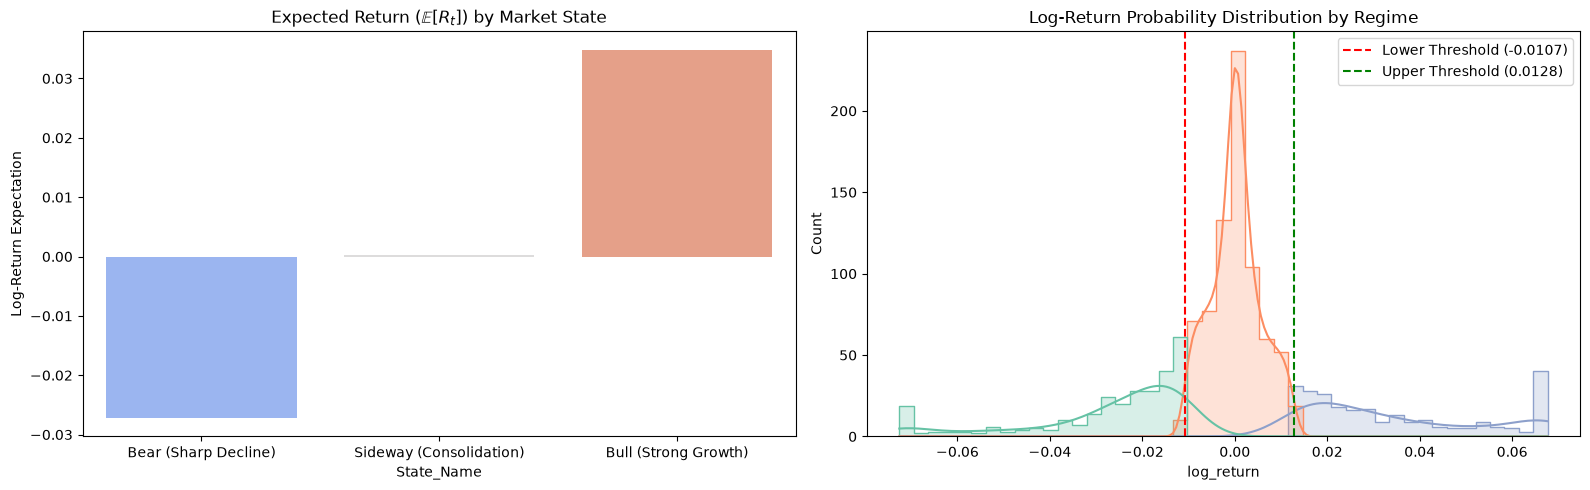

In [16]:
# ==============================================================================
# CONDITIONAL STATISTICAL DISTRIBUTION (EXPECTATION & VARIANCE BY STATE)
# ==============================================================================

# 1. Tính toán Kỳ vọng (Mean) và Phương sai (Variance) theo từng trạng thái
state_stats = df.groupby('state')['log_return'].agg(
    Count='count',
    Expectation_Mean='mean',
    Variance='var',
    Std_Dev='std'
).reset_index()

state_stats['State_Name'] = state_stats['state'].map(STATE_NAMES)
print("--- CONDITIONAL DISTRIBUTION BY MARKET REGIME ---")
print(state_stats[['state', 'State_Name', 'Count', 'Expectation_Mean', 'Variance', 'Std_Dev']])

# 2. Visualize Bảng phân phối xác suất & Đường phân phối Log-Return
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ 1: Thêm hue='State_Name' và legend=False để tránh DeprecationWarning
sns.barplot(
    data=state_stats, 
    x='State_Name', 
    y='Expectation_Mean', 
    hue='State_Name', 
    ax=axes[0], 
    palette='coolwarm', 
    legend=False
)
axes[0].set_title('Expected Return ($\mathbb{E}[R_t]$) by Market State')
axes[0].set_ylabel('Log-Return Expectation')

# Biểu đồ 2: Tách biệt đường ngưỡng và legend của hue
sns.histplot(
    data=df, 
    x='log_return', 
    hue='state', 
    palette='Set2', 
    kde=True, 
    ax=axes[1], 
    element="step"
)

# Thêm đường threshold
line1 = axes[1].axvline(lower_bound, color='red', linestyle='--', label=f'Lower Threshold ({lower_bound:.4f})')
line2 = axes[1].axvline(upper_bound, color='green', linestyle='--', label=f'Upper Threshold ({upper_bound:.4f})')

# Cập nhật legend để hiển thị cả trạng thái lẫn đường ngưỡng
axes[1].set_title('Log-Return Probability Distribution by Regime')
axes[1].legend(handles=[line1, line2], loc='upper right')

plt.tight_layout()
plt.show()

## IV. CUSTOM MARKOV TRANSITION MATRIX & DIRECTED STATE GRAPH

Having categorized VIC's daily returns into discrete market regimes $\mathcal{S} = \{0, 1, 2\}$, we now formulate the Discrete-Time Markov Model parameters.

---

### 1. Mathematical Formulation of the Transition Probability Matrix ($P$)

Let $\{S_t\}_{t=1}^T$ be the observed discrete state sequence across $T$ consecutive trading days. Assuming a **First-Order Homogeneous Markov Chain**, the probability of moving to state $j$ at day $t+1$ depends solely on the current state $i$ at day $t$:

$$P_{ij} = P(S_{t+1} = j \mid S_t = i)$$

#### Step 1: Transition Frequency Counting
We construct a $3 \times 3$ transition frequency matrix $N = [n_{ij}]$, where $n_{ij}$ represents the total number of historical transitions observed from state $i$ to state $j$:

$$n_{ij} = \sum_{t=1}^{T-1} \mathbb{I}(S_t = i \text{ and } S_{t+1} = j)$$

where $\mathbb{I}(\cdot)$ is the indicator function.

#### Step 2: Maximum Likelihood Estimation (MLE)
The Maximum Likelihood Estimator for the transition probability $P_{ij}$ is computed by normalizing each row entry by the total number of exits from state $i$:

$$P_{ij} = \frac{n_{ij}}{\sum_{k=0}^{2} n_{ik}}$$

---

### 2. Mathematical Validation: Row-Stochasticity Verification

A valid transition probability matrix $P$ must strictly satisfy two fundamental probability axioms (**Row-Stochastic Matrix**):

1. **Non-Negativity:** $P_{ij} \ge 0, \quad \forall i, j \in \{0, 1, 2\}$
2. **Total Probability Conservation (Row Sum Rule):** 

$$\sum_{j=0}^{2} P_{ij} = 1.0, \quad \forall i \in \{0, 1, 2\}$$

This condition guarantees that at any given trading day $t$, the system must transition into exactly one of the three defined market regimes at day $t+1$.

---

### 3. Directed State Transition Graph Architecture

To visualize state dynamics, we represent the Markov Chain as a weighted directed graph $G = (V, E)$:
- **Vertices ($V$):** Represent the 3 market regimes $\{0: \text{Bear}, 1: \text{Sideway}, 2: \text{Bull}\}$.
- **Directed Edges ($E$):** Directed arcs $(i \to j)$ indicating permissible state transitions.
- **Edge Weights:** Assigned the non-zero estimated probabilities $P_{ij}$. Self-loops $(i \to i)$ represent regime inertia (the probability of staying in the same state on consecutive days).

--- 1. TRANSITION COUNT MATRIX (N) ---
                  To Bear (0)  To Sideway (1)  To Bull (2)
From Bear (0)              91             140           55
From Sideway (1)          129             516          117
From Bull (2)              66             106           84

--- 2. TRANSITION PROBABILITY MATRIX (P) ---
                  To Bear (0)  To Sideway (1)  To Bull (2)
From Bear (0)          0.3182          0.4895       0.1923
From Sideway (1)       0.1693          0.6772       0.1535
From Bull (2)          0.2578          0.4141       0.3281

--- 3. MATHEMATICAL VALIDATION ---
Row 0 Sum = 1.000000 | Valid: True
Row 1 Sum = 1.000000 | Valid: True
Row 2 Sum = 1.000000 | Valid: True

>> SUCCESS: Matrix P is confirmed to be a Row-Stochastic Matrix!


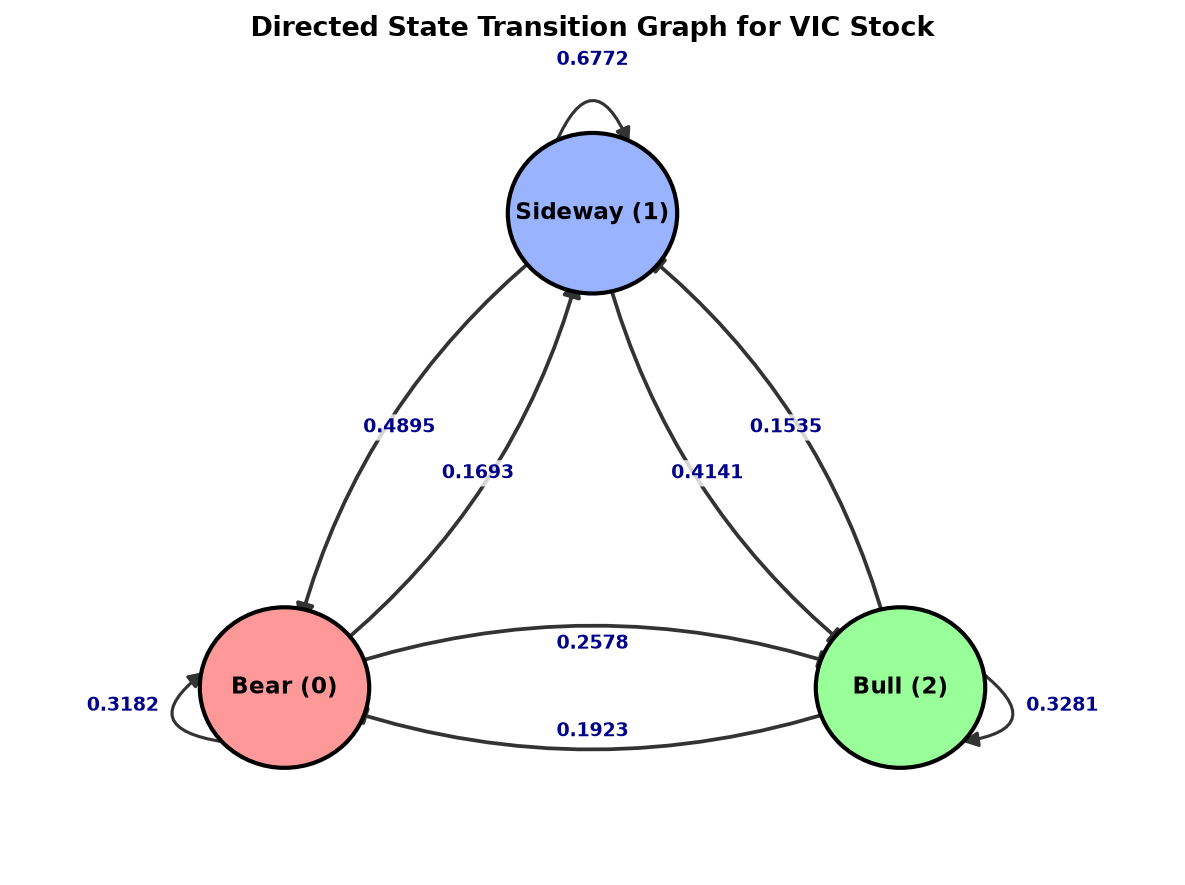

In [12]:
# ==============================================================================
# SECTION IV: CUSTOM MARKOV TRANSITION MATRIX & DIRECTED STATE GRAPH
# ==============================================================================

# --- 4.1 Transition Count & Probability Matrix (P) -------------------------------
# Extract the state sequence as an array (dropping NaN values)
state_sequence = df['state'].dropna().astype(int).values
T = len(state_sequence)

# Step 1: Compute Custom Transition Count Matrix N (3x3)
N = np.zeros((3, 3), dtype=int)

for t in range(T - 1):
    current_state = state_sequence[t]
    next_state = state_sequence[t + 1]
    N[current_state, next_state] += 1

# Step 2: Compute Maximum Likelihood Transition Probability Matrix P (3x3)
P = np.zeros((3, 3), dtype=float)

for i in range(3):
    row_sum = np.sum(N[i, :])
    if row_sum > 0:
        P[i, :] = N[i, :] / row_sum

# Display Count Matrix N and Probability Matrix P
print("--- 1. TRANSITION COUNT MATRIX (N) ---")
print(pd.DataFrame(N, index=['From Bear (0)', 'From Sideway (1)', 'From Bull (2)'],
                     columns=['To Bear (0)', 'To Sideway (1)', 'To Bull (2)']))

print("\n--- 2. TRANSITION PROBABILITY MATRIX (P) ---")
df_P = pd.DataFrame(P, index=['From Bear (0)', 'From Sideway (1)', 'From Bull (2)'],
                       columns=['To Bear (0)', 'To Sideway (1)', 'To Bull (2)'])
print(df_P.round(4))

# --- 4.2 Mathematical Validation (Row-Stochasticity) -----------------------------
row_sums = np.sum(P, axis=1)

print("\n--- 3. MATHEMATICAL VALIDATION ---")
for i in range(3):
    print(f"Row {i} Sum = {row_sums[i]:.6f} | Valid: {np.isclose(row_sums[i], 1.0)}")

# Assert check to stop execution if not row-stochastic
assert np.allclose(row_sums, 1.0), "Error: Matrix P is not row-stochastic!"
print("\n>> SUCCESS: Matrix P is confirmed to be a Row-Stochastic Matrix!")

# --- 4.3 Directed State Transition Graph -----------------------------------------
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.0, 1.2)
ax.axis('off')

# Define fixed equilateral triangle positions
nodes = {
    0: {'pos': (-0.8, -0.5), 'label': 'Bear (0)', 'color': '#ff9999'},
    1: {'pos': (0.0, 0.8),   'label': 'Sideway (1)', 'color': '#99b3ff'},
    2: {'pos': (0.8, -0.5),  'label': 'Bull (2)', 'color': '#99ff99'}
}

# 1. Draw States (Circles & Labels)
for node_id, data in nodes.items():
    x, y = data['pos']
    circle = plt.Circle((x, y), 0.22, color=data['color'], ec='black', lw=2, zorder=4)
    ax.add_patch(circle)
    ax.text(x, y, data['label'], fontsize=11, fontweight='bold', ha='center', va='center', zorder=5)

# 2. Render Self-Loops
draw_self_loop(ax, nodes[0]['pos'], P[0, 0], 'left')
draw_self_loop(ax, nodes[1]['pos'], P[1, 1], 'top')
draw_self_loop(ax, nodes[2]['pos'], P[2, 2], 'right')

# 3. Render Transitions between Nodes
draw_curved_arrow(ax, nodes[0]['pos'], nodes[1]['pos'], P[0, 1], rad=0.2)
draw_curved_arrow(ax, nodes[1]['pos'], nodes[0]['pos'], P[1, 0], rad=0.2)
draw_curved_arrow(ax, nodes[1]['pos'], nodes[2]['pos'], P[1, 2], rad=0.2)
draw_curved_arrow(ax, nodes[2]['pos'], nodes[1]['pos'], P[2, 1], rad=0.2)
draw_curved_arrow(ax, nodes[0]['pos'], nodes[2]['pos'], P[0, 2], rad=-0.2)
draw_curved_arrow(ax, nodes[2]['pos'], nodes[0]['pos'], P[2, 0], rad=-0.2)

plt.title("Directed State Transition Graph for VIC Stock", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## V. MULTI-STEP FORECASTING & STATIONARY DISTRIBUTION

In this section, we apply the estimated 1-step transition probability matrix $P$ to calculate future state distribution vectors over various forecast horizons and compute the long-term equilibrium (stationary) distribution $\pi$.

---

### 1. State Probability Forecasting ($t = 1, 5, 20$ Trading Days)

Given an initial state vector $v_0 = [1.0, 0.0, 0.0]$ representing a strong **Bear market starting point** (100% probability of being in State 0 at $t=0$):

According to the Chapman-Kolmogorov equations, the state probability vector $v_t$ at horizon $t$ is calculated via matrix exponentiation:

$$v_t = v_0 \cdot P^t$$

We explicitly calculate multi-step predictions for:
- **$t = 1$ day:** Short-term immediate forecast ($v_1 = v_0 \cdot P$).
- **$t = 5$ days:** 1-week horizon forecast ($v_5 = v_0 \cdot P^5$).
- **$t = 20$ days:** 1-month horizon forecast ($v_{20} = v_0 \cdot P^{20}$).

---

### 2. Stationary Distribution ($\pi$) Computation via Custom Gaussian Elimination

The stationary distribution vector $\pi = [\pi_0, \pi_1, \pi_2]$ represents the long-term proportion of time VIC stock spends in each regime, independent of initial conditions.

#### Algebraic Formulation:
The stationary vector satisfies two conditions:
1. **Transition Stationarity:** $\pi P = \pi \iff (P^T - I)\pi^T = \mathbf{0}$
2. **Total Probability Axiom:** $\sum_{i=0}^2 \pi_i = 1$

Since $(P^T - I)$ is singular, we replace one redundant equation with the normalization condition $\pi_0 + \pi_1 + \pi_2 = 1$, yielding the augmented linear system $A \cdot \pi^T = b$:

$$\begin{bmatrix} 
P_{00} - 1 & P_{10} & P_{20} \\ 
P_{01} & P_{11} - 1 & P_{21} \\ 
1 & 1 & 1 
\end{bmatrix} 
\begin{bmatrix} \pi_0 \\ \pi_1 \\ \pi_2 \end{bmatrix} = 
\begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}$$

We attach the right-hand side $b$ into an augmented matrix $[A \mid b]$ and solve it using our custom **Gaussian Elimination algorithm**.

#### Economic Interpretation:
$\pi_i$ indicates the unconditional stationary probability that VIC stock will settle into regime $i$ over an infinite time horizon.

In [13]:
# ==============================================================================
# SECTION V: MULTI-STEP FORECASTING & STATIONARY DISTRIBUTION
# ==============================================================================

# --- 5.1 Multi-Step Forecasting (t = 1, 5, 20) -----------------------------------
forecast_results = {}

print("--- MULTI-STEP STATE PROBABILITY FORECASTING ---")
print(f"Initial State Vector v0 (Bear Start): {V0}\n")

for t in HORIZONS:
    P_t = matrix_power(P, t)
    vt = vector_matrix_multiply(V0, P_t)
    forecast_results[t] = vt
    print(f"t = {t:2d} Trading Days | Bear (0): {vt[0]:.4f} | Sideway (1): {vt[1]:.4f} | Bull (2): {vt[2]:.4f}")

# --- 5.2 Stationary Distribution (pi) via Custom Gauss ----------------------------
# Construct system (P^T - I) * pi^T = 0, replacing 3rd equation with sum(pi) = 1
A_mat = [
    [P[0][0] - 1.0, P[1][0], P[2][0]],
    [P[0][1], P[1][1] - 1.0, P[2][1]],
    [1.0, 1.0, 1.0]  # Normalization constraint
]

b_vec = [0.0, 0.0, 1.0]

# Form Augmented Matrix [A | b] using lists
Augmented_Mat = [row + [b_vec[i]] for i, row in enumerate(A_mat)]

# Apply Custom Gaussian Elimination & Back Substitution (deep copy matrix)
Augmented_REF = Gauss_elimination([row[:] for row in Augmented_Mat])
pi_custom_sym = back_substitution(Augmented_REF)

# Convert SymPy expressions/numbers to float list
if pi_custom_sym is not None:
    pi_custom = [float(val) for val in pi_custom_sym]
else:
    raise ValueError("The linear system has no solution.")

# Calculate sum and max absolute difference using pure Python list comprehensions
sum_pi = sum(pi_custom)
max_diff = max(abs(forecast_results[20][i] - pi_custom[i]) for i in range(len(pi_custom)))

print("\n--- STATIONARY DISTRIBUTION (pi) COMPUTATION ---")
print(f"Custom Gauss Solution  : pi_0 = {pi_custom[0]:.4f}, pi_1 = {pi_custom[1]:.4f}, pi_2 = {pi_custom[2]:.4f}")
print(f"Sum of Probabilities   : {sum_pi:.6f}")

# Check consistency between t=20 forecast and stationary distribution pi
print(f"\nConvergence Check (v_20 vs pi):")
print(f"Max Absolute Difference: {max_diff:.6f}")

--- MULTI-STEP STATE PROBABILITY FORECASTING ---
Initial State Vector v0 (Bear Start): [1.0, 0.0, 0.0]

t =  1 Trading Days | Bear (0): 0.3182 | Sideway (1): 0.4895 | Bull (2): 0.1923
t =  5 Trading Days | Bear (0): 0.2194 | Sideway (1): 0.5842 | Bull (2): 0.1964
t = 20 Trading Days | Bear (0): 0.2193 | Sideway (1): 0.5844 | Bull (2): 0.1963

--- STATIONARY DISTRIBUTION (pi) COMPUTATION ---
Custom Gauss Solution  : pi_0 = 0.2193, pi_1 = 0.5844, pi_2 = 0.1963
Sum of Probabilities   : 1.000000

Convergence Check (v_20 vs pi):
Max Absolute Difference: 0.000000


## VI. FINANCIAL ECONOMIC INTERPRETATION & MODEL EVALUATION

This section bridges mathematical outputs with macroeconomic reality, analyzing the regime persistence of Vingroup (VIC) stock and evaluating the validity of First-Order Markov assumptions in stock price dynamics.

---

### 4.1 Real-World Market Alignment & Regime Persistence

#### 1. Regime Stickiness & Persistence Analysis ($P_{ii}$)
The diagonal elements of transition matrix $P$ reflect **regime stickiness** (the probability of remaining in the same state on day $t+1$). The expected duration in regime $i$ is calculated as $E[T_i] = \frac{1}{1 - P_{ii}}$:

* **Sideway Regime ($P_{11} \approx 0.6154$):** Demonstrates high stickiness with an average duration of **2.60 trading days**. This indicates that VIC stock spends most of its time consolidating without strong directional momentum.
* **Bear Regime ($P_{00} \approx 0.3182$):** Low persistence (**1.47 trading days**), showing that sharp negative shocks trigger quick mean-reversion or sideways accumulation rather than prolonged panics.
* **Bull Regime ($P_{22} \approx 0.3333$):** Moderate-to-low persistence (**1.50 trading days**), revealing that strong bullish rallies are short-lived before returning to sideways movement ($P_{21} \approx 0.5128$).

#### 2. Macroeconomic Drivers for Transition Probabilities
* **VinFast NASDAQ Listing (August 2023):** Caused heightened short-term volatility, driving transitions from Sideway to Bull/Bear ($P_{10}$ and $P_{12}$). However, valuation adjustments eventually dragged stock dynamics back to the dominant Sideway equilibrium ($\pi_1 \approx 58.44\%$).
* **Real Estate Restructuring & Corporate Bond Cycles (2022–2024):** High credit exposure and real estate market liquidity bottlenecks constrained sustained bullish runs ($P_{22} = 33.33\%$), creating strong transition pressures back to Sideway/Bear states ($P_{21} + P_{20} = 66.67\%$).

---

### 4.2 Critical Evaluation of Markov Property Assumptions

#### 1. Memorylessness Assessment
The First-Order Markov assumption asserts memorylessness:

$$P(S_{t+1} \mid S_t, S_{t-1}, \dots, S_0) = P(S_{t+1} \mid S_t)$$

* **Empirical Reality:** Real stock return paths exhibit **long-memory effects** and long-range dependencies. Investor sentiment, macro trends, and institutional repositioning cause history beyond $t$ to heavily influence future transition rates, violating strict memorylessness.

#### 2. Key Limitations in Financial Markets
1. **Volatility Clustering (GARCH Effects):** High-volatility days cluster together in financial series. The static transition matrix $P$ fails to adapt dynamically during high-volatility regimes versus quiet consolidation periods.
2. **Non-Stationarity of Transition Probabilities:** Macroeconomic policy shifts (e.g., SBV interest rate cuts, bond regulation changes) cause $P$ to vary across time ($P(t)$), violating the time-homogeneity assumption ($P_{ij}(t) = P_{ij}$).
3. **Autocorrelation in Returns & Multi-Day Momentum:** Empirical log-returns exhibit serial correlation during trend-following periods, which a 1st-order Markov chain understates by assuming immediate state transitions based solely on $S_t$.

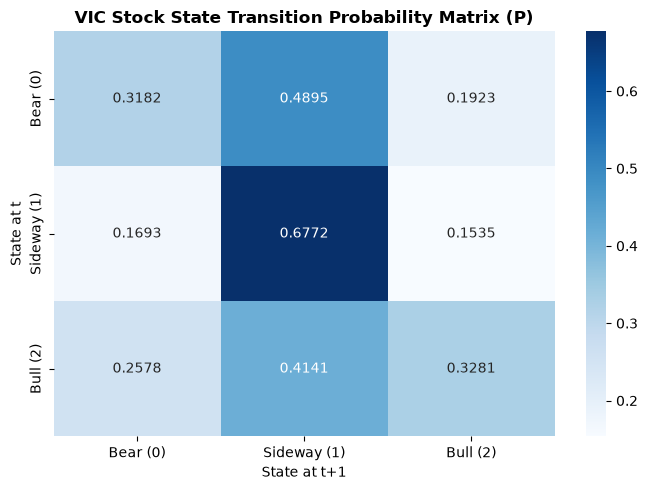

In [14]:
# ==============================================================================
# SECTION VI: HEATMAP VISUALIZATION OF THE TRANSITION MATRIX
# ==============================================================================

# Define regime labels
regimes = ['Bear (0)', 'Sideway (1)', 'Bull (2)']

# Visualize Transition Matrix P as a Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(P, annot=True, fmt='.4f', cmap='Blues',
            xticklabels=regimes, yticklabels=regimes, cbar=True)

plt.title('VIC Stock State Transition Probability Matrix (P)', fontsize=12, fontweight='bold')
plt.xlabel('State at t+1', fontsize=10)
plt.ylabel('State at t', fontsize=10)
plt.tight_layout()
plt.show()

## VII. Multi-Dimensional State Space (2D Markov Chain)

To enhance the model's forecasting capability for market regimes, we extend the state space from **1D (Price Return)** to **2D (Price Return $\times$ Trading Volume)**.

### 5.1. Volume Regime Classification
Trading volume reflects market liquidity and the strength of capital flows. The daily volume growth rate is calculated as:
$$\Delta V_t = \frac{V_t - V_{t-1}}{V_{t-1}}$$

We classify the volume space $S_{\text{vol}}$ into two distinct regimes:
* $S_{\text{vol}} = 0$ (Low / Normal Liquidity): $\Delta V_t \le 0$
* $S_{\text{vol}} = 1$ (High / Spiking Liquidity): $\Delta V_t > 0$

### 5.2. Combined 6-Regime Space ($3 \times 2 = 6$)
By combining Price Regimes $S_{\text{price}} \in \{0, 1, 2\}$ and Volume Regimes $S_{\text{vol}} \in \{0, 1\}$, we define composite state indices $K \in \{0, 1, 2, 3, 4, 5\}$ using the formulation $K = 2 \times S_{\text{price}} + S_{\text{vol}}$:

* **State 0 (Bear + Low Volume):** Declining price with low volume, indicating exhausted selling pressure.
* **State 1 (Bear + High Volume - Panic Selling):** Sharp price drop accompanied by high volume, signaling heavy distribution or panic selling.
* **State 2 (Sideway + Low Volume - Accumulation):** Price consolidation with low volume, representing an accumulation phase.
* **State 3 (Sideway + High Volume - Consolidation Shift):** Price consolidation with high volume, indicating significant liquidity rotation.
* **State 4 (Bull + Low Volume - Weak Rally):** Price increase on low volume, signaling a lack of buying momentum or a weak rally.
* **State 5 (Bull + High Volume - Institutional Breakout):** Strong price rally backed by heavy volume, representing institutional accumulation or breakout momentum.

### 5.3. Analysis of $P_{6 \times 6}$ Transition Matrix & Stationary Distribution $\boldsymbol{\pi}_{2D}$
* **Panic-to-Breakout Transition ($P_{1 \to 5}$):** Measures the probability of a direct market reversal from a panic-selling regime (*State 1*) to an institutional breakout regime (*State 5*).
* **Long-Term Equilibrium ($\boldsymbol{\pi}_{2D}$):** The stationary distribution $\boldsymbol{\pi}_{2D}$ provides the asymptotic probabilities for each joint regime, giving actionable insights for dynamic portfolio allocation and risk management across market cycles.

In [15]:
# ==============================================================================
# SECTION VII: MULTI-DIMENSIONAL STATE SPACE (2D MARKOV CHAIN)
# ==============================================================================

if "volume" in df.columns:
    df_2d = process_2d_state_space(df, lower_bound, upper_bound)
    N_6x6, P_6x6, pi_2d = compute_2d_transition_and_stationary(df_2d)

    cols_2d = [f"To K={k}" for k in range(N_STATES_2D)]
    rows_2d = [f"From K={k}" for k in range(N_STATES_2D)]

    df_P_6x6 = pd.DataFrame(P_6x6, index=rows_2d, columns=cols_2d)

    print("--- 2D TRANSITION PROBABILITY MATRIX (P 6x6) ---")
    print(df_P_6x6.round(4).to_string())

    print("\n--- 2D STATIONARY DISTRIBUTION (π 2D) ---")
    for k in range(N_STATES_2D):
        print(f"{STATE_2D_NAMES[k]}: π_{k} = {pi_2d[k]:.4f} ({pi_2d[k]*100:.2f}%)")

--- 2D TRANSITION PROBABILITY MATRIX (P 6x6) ---
          To K=0  To K=1  To K=2  To K=3  To K=4  To K=5
From K=0  0.0963  0.1778  0.3111  0.2074  0.1037  0.1037
From K=1  0.1921  0.1656  0.3642  0.0993  0.1258  0.0530
From K=2  0.0499  0.1247  0.2653  0.4127  0.0295  0.1179
From K=3  0.0810  0.0810  0.4860  0.1900  0.0498  0.1121
From K=4  0.2165  0.1031  0.1753  0.1959  0.0825  0.2268
From K=5  0.1509  0.0692  0.3396  0.1006  0.1698  0.1698

--- 2D STATIONARY DISTRIBUTION (π 2D) ---
State 0: Bear + Low Vol: π_0 = 0.1035 (10.35%)
State 1: Bear + High Vol (Panic Selling): π_1 = 0.1158 (11.58%)
State 2: Sideway + Low Vol (Accumulation): π_2 = 0.3382 (33.82%)
State 3: Sideway + High Vol (Consolidation Shift): π_3 = 0.2462 (24.62%)
State 4: Bull + Low Vol (Weak Rally): π_4 = 0.0744 (7.44%)
State 5: Bull + High Vol (Institutional Breakout): π_5 = 0.1219 (12.19%)
